# Reproducible comparison of JDR clustering on 100 light curves

**Version 2 spectral representation · full local census · publication figure exports**

This notebook recomputes every period fit, compares five clustering models, runs numerical and stability checks, repeats the entire experiment independently, and exports four multi-panel figures with source data and captions. Use **Restart Kernel → Run All** in the environment installed from `requirements-dev.txt`.

**Scope.** These are all 100 locally available RR Lyrae curves, not a randomly drawn or held-out test set: 68 RRab, 31 RRc and one RRd. Region composition is BLG 50, GD 45 and LMC 5. A single RRd does not permit meaningful class-level performance inference. High-quality graphics do not establish publication-level scientific validity; additional independent data and photometric/period uncertainty analysis are needed for that claim.

**Outputs.** All new results go to `results/benchmark_100/`. Existing source observations and older experiment results are not deleted. The second independent run uses a temporary directory. No network access or dataset downloads are needed.

In [1]:
from pathlib import Path
import os
import sys
import json
import tempfile
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'benchmark.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
from src.benchmark import PROTOCOL, cohort, run_benchmark, compare_runs, MODEL_NAMES
from src.publication_figures import make_figures
OUTPUT = ROOT / 'results' / 'benchmark_100'


## 1. Freeze the protocol before inspecting model scores

Every matrix-based model receives **sqrt(J)**, the Euclidean distance of the shared spectral embedding. K-means receives that exact embedding; it minimizes a squared-Euclidean objective rather than a medoid objective. No PCA truncation is used for clustering.

K=3 is a fixed reference choice for partitioning models, not optimized with catalog labels. K-medoids and k-means use 20 starts. DBSCAN uses `min_samples=5` (including the point itself) and the 0.70 quantile of the fourth-other-neighbor distance. HDBSCAN uses minimum cluster size 5 and minimum samples 5. Density methods may return a different number of clusters.

The primary results are not selected from the later sensitivity curves. All models share the same fitted curves, distance geometry and deterministic object order. Internal silhouette scores are calculated on assigned objects using sqrt(J) and must be interpreted with coverage.

In [2]:
display(pd.Series(PROTOCOL, name='Fixed protocol').to_frame())
files, census, catalogs = cohort()
assert len(files) == 100 and census.object_id.is_unique
assert len(set(census.sha256)) == 100
assert census.catalog_type.value_counts().to_dict() == {'RRab': 68, 'RRc': 31, 'RRd': 1}
display(pd.crosstab(census.region, census.catalog_type, margins=True))


,Fixed protocol
version,1
n_objects,100
seed,20260912
n_clusters,3
n_init,20
dbscan_min_samples,5
dbscan_eps_quantile,0.7
hdbscan_min_cluster_size,5
hdbscan_min_samples,5
subsamples,30


catalog_type,RRab,RRc,RRd,All
region,,,,
BLG,27,22,1,50
GD,36,9,0,45
LMC,5,0,0,5
All,68,31,1,100


## 2. Recompute preprocessing, distances and model fits

Raw irregular observations remain unchanged. Periods are estimated from all observations with measurement errors, candidate peaks and half/double-period alternatives. BIC chooses harmonic complexity; a smooth fitted brightest phase defines alignment. Fitted phase curves use 256 points.

The standard JDR representation fits a floating mean and common-basis cosine/sine amplitudes; its shared band is **0.5–6 cycles per phase**. This is the documented version 2 representation, not an asserted exact reproduction of an unidentified original JDR paper. Old matrices and eps values cannot be reused.

Three frequency resolutions (1025, 2049 and 4097) must agree entrywise with `rtol=1e-3`, `atol=1e-8`, and preserve every nearest-neighbor identity. The final, finest matrix is used in this experiment. A failure raises an exception; there is no silent filtering or tolerance relaxation.

In [3]:
run_benchmark(OUTPUT)
summary = json.loads((OUTPUT / 'summary.json').read_text())
scores = pd.read_csv(OUTPUT / 'model_comparison.csv').set_index('model').loc[MODEL_NAMES]
cohort_table = pd.read_csv(OUTPUT / 'cohort.csv')
with np.load(OUTPUT / 'experiment.npz', allow_pickle=False) as archive:
    D = archive['distance'].copy()
    J = archive['J'].copy()
assert D.shape == (100, 100) and np.isfinite(D).all()
assert np.array_equal(np.diag(D), np.zeros(100))
assert np.all(D >= 0) and np.allclose(D, D.T)
assert np.allclose(D**2, J)
assert summary['permutation_invariance']
assert summary['fit_info']['dbscan_reference_agreement']
display(pd.DataFrame(summary['grid_convergence']))


Folded 20/100 light curves


Folded 40/100 light curves


Folded 60/100 light curves


Folded 80/100 light curves


Folded 100/100 light curves


,coarse_grid,fine_grid,relative_max_error,all_pairs_close,neighbor_agreement
0,1025,2049,0.000007,True,1.0
1,2049,4097,0.000002,True,1.0


## 3. Compare models without hiding rejected curves

ARI and AMI below use all 100 curves. Noise is represented by label −1; therefore all-noise points count as one group in these indices. Assigned-only ARI, purity and silhouette are reported separately, never without coverage. Purity alone is not an acceptable selection objective: a one-cluster majority-class baseline has purity 0.68, and small retained subsets can have misleadingly high purity.

In [4]:
display(scores[['ari_all', 'ami_all', 'coverage', 'n_clusters', 'n_noise',
                'purity_assigned', 'ari_assigned', 'silhouette_assigned']].round(4))
retention = pd.DataFrame({name: summary['models'][name]['class_retention'] for name in MODEL_NAMES}).T
display(retention.rename_axis('model').round(3))


,ari_all,ami_all,coverage,n_clusters,n_noise,purity_assigned,ari_assigned,silhouette_assigned
model,,,,,,,,
K-medoids,0.6044,0.5566,1.00,3,0,0.9200,0.6044,0.5811
K-means,0.6235,0.5658,1.00,3,0,0.9200,0.6235,0.5835
Average linkage,0.6994,0.5690,1.00,3,0,0.9200,0.6994,0.5024
DBSCAN,0.5358,0.5260,0.78,2,22,0.9744,0.9316,0.8230
HDBSCAN,0.7603,0.6063,0.98,2,2,0.9388,0.7909,0.7112


,RRab,RRc,RRd
model,,,
K-medoids,1.000,1.000,1.0
K-means,1.000,1.000,1.0
Average linkage,1.000,1.000,1.0
DBSCAN,0.765,0.806,1.0
HDBSCAN,0.985,0.968,1.0


## 4. Assess stability and sensitivity

Each model is refitted on the same 30 deterministic 80-object subsamples. Stability compares each new partition with the full-data partition restricted to that subset. DBSCAN recalculates its fixed distance-quantile rule within each subset. The exported table also contains ARI on objects assigned in both fits and that common-assigned fraction.

The displayed 10th/50th/90th percentiles describe **clustering stability**, not confidence intervals for generalization performance. Subsamples overlap, and the fitted light curves remain fixed; this does not propagate period uncertainty or simulate new independent observations.

The complete DBSCAN sensitivity grid uses neighborhood sizes 3, 5 and 8 and 18 eps quantiles from 0.10 to 0.95. It is shown diagnostically and does not replace the predeclared primary settings.

In [5]:
stability = pd.read_csv(OUTPUT / 'subsampling_stability.csv')
assert stability.shape[0] == 30 * len(MODEL_NAMES)
stability_summary = stability.groupby('model')['ari_stability_all'].quantile([.1, .5, .9]).unstack().reindex(MODEL_NAMES)
stability_summary.columns = ['10th percentile', 'Median', '90th percentile']
display(stability_summary.round(3))
sensitivity = pd.read_csv(OUTPUT / 'dbscan_sensitivity.csv')
assert len(sensitivity) == 3 * 18
# Region agreement is descriptive, not proof that region is or is not a confounder.
display(scores[['ari_all', 'ari_region_all']].round(4))


,10th percentile,Median,90th percentile
model,,,
K-medoids,0.993,1.000,1.000
K-means,0.921,1.000,1.000
Average linkage,0.623,0.750,0.964
DBSCAN,0.864,0.926,1.000
HDBSCAN,0.680,0.963,1.000


,ari_all,ari_region_all
model,,
K-medoids,0.6044,0.0362
K-means,0.6235,0.0320
Average linkage,0.6994,0.0026
DBSCAN,0.5358,0.0508
HDBSCAN,0.7603,0.0065


## 5. Independent reproducibility check

The second run starts from the original 100 files again: all period fits, features, model starts, subsampling refits and sensitivity calculations are recomputed. No folded-curve cache is read. Exact numerical arrays, tables, configurations and provenance must match in the recorded environment. Figure/PDF compression timestamps are not a meaningful numerical reproducibility criterion.

Different BLAS implementations, processor architectures or package versions may change floating-point results; environment versions, source hashes and ordered input hashes are saved. Use the supplied environment lock for the closest reproduction.

In [6]:
with tempfile.TemporaryDirectory(prefix='jdr100-repeat-') as temporary:
    repeat = run_benchmark(Path(temporary))
    reproducibility = compare_runs(OUTPUT, repeat)
assert reproducibility['arrays_identical'] and reproducibility['tables_identical']
display(pd.Series(reproducibility, name='Verification').to_frame())


Folded 20/100 light curves


Folded 40/100 light curves


Folded 60/100 light curves


Folded 80/100 light curves


Folded 100/100 light curves


,Verification
independent_full_recomputations,2
tables_identical,True
arrays_identical,True
provenance_identical,True
comparison,"Exact within the recorded environment, not pro..."


## 6. Export and inspect journal-scale figures

Each figure is 183 mm wide, with 7-point main type, 6-point ticks, 8-point panel labels, accessible colors, and explicit scales. PDF/SVG retain vector linework and editable text; PNG is exported at 600 dpi. The notebook embeds smaller previews, not the submission-resolution images. There are no decorative effects, smoothed heatmaps, unlabelled error bars or implied confidence intervals.

The layout follows the [Nature research figure guide](https://research-figure-guide.nature.com/figures/preparing-figures-our-specifications/) as a starting point. Final submission requirements depend on the destination journal. Source CSVs, selected representative IDs, matrix display order and full captions are exported.

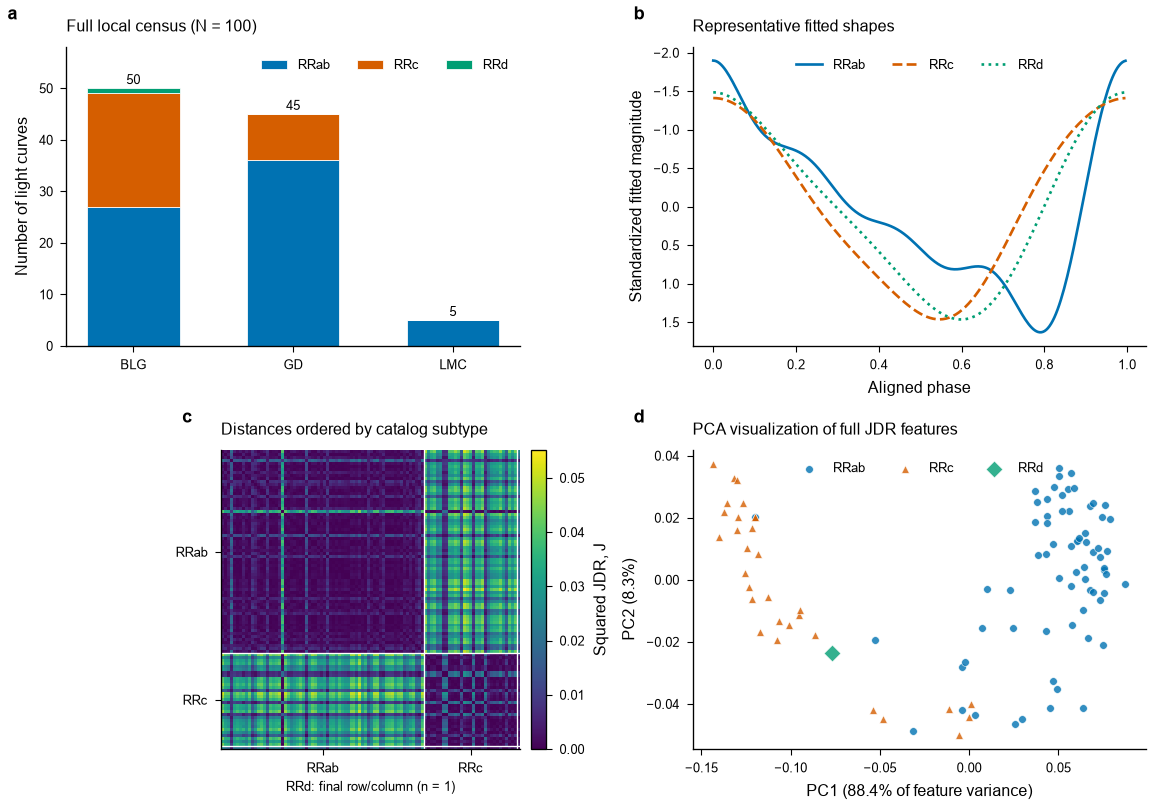

Figure 1 | Local cohort and JDR geometry. a, Catalog composition by sky region (BLG, Galactic bulge; GD, Galactic disk; LMC, Large Magellanic Cloud). All 100 available curves are included. b, Standardized, fitted periodic shapes of within-subtype distance medoids, selected for display only; these are model fits, not raw photometry or uncertainty bands. c, Squared-JDR matrix ordered by catalog subtype, then region and ID; the singleton RRd is indicated. Clustering uses sqrt(J). d, Two-component PCA of the full spectral embedding, colored by catalog subtype. PCA is used only for visualization; all clustering uses the full embedding or its distances. Source IDs, display order and values are exported. RRd has only one object.

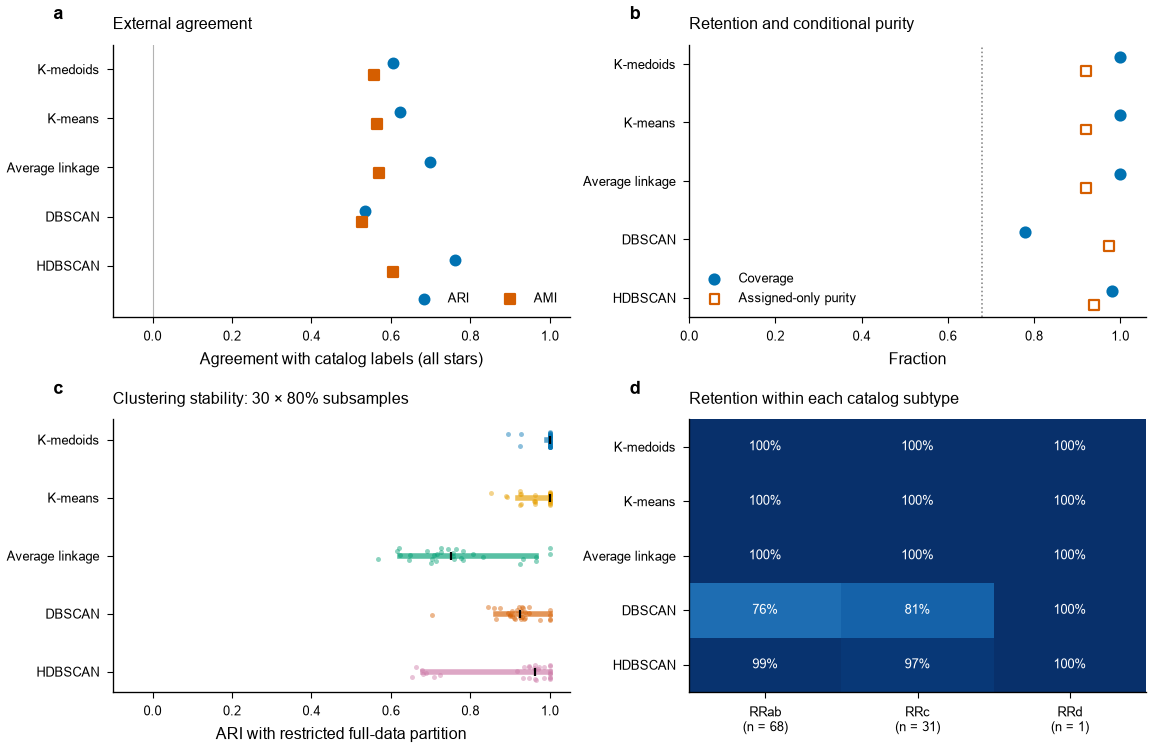

Figure 2 | Comparison under the fixed protocol. a, Adjusted Rand index (ARI) and adjusted mutual information (AMI) against catalog labels, evaluated on all 100 objects; rejected points share label −1. b, Assigned fraction and purity conditional on assignment; dotted line is the 0.68 majority-class fraction, not a performance threshold. c, Clustering is refitted on 30 reproducible, shared 80-object subsets using fixed policies; dots are replicate ARIs against the full partition restricted to the subset, thick segments show empirical 10th–90th percentiles and black ticks show medians. These are stability summaries, not confidence intervals, independent repetitions of data collection, or photometric/period uncertainty propagation. DBSCAN recalculates its prescribed distance quantile within each subset. d, Within-subtype retention, with denominators shown. A 100% value for the one RRd object is not evidence of generalizable RRd recovery.

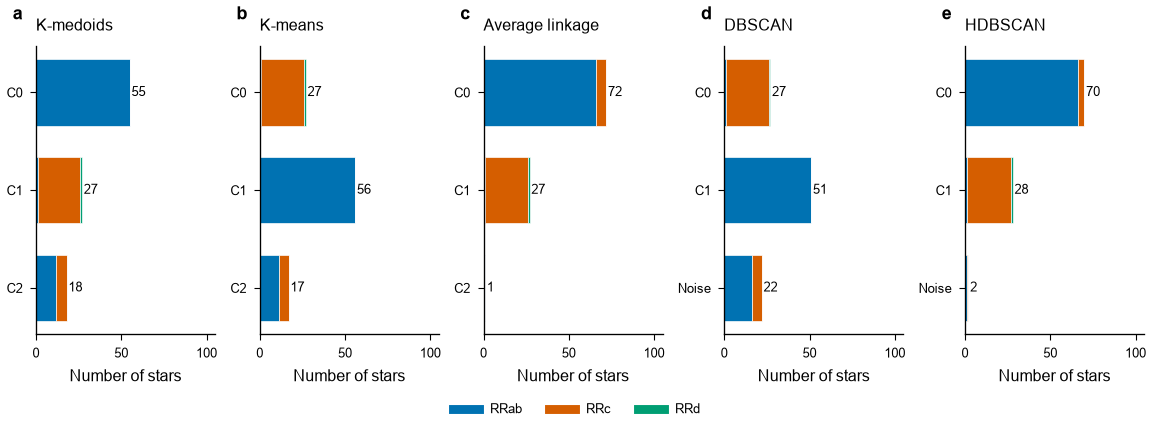

Figure 3 | Catalog composition of every learned cluster. Bar segments are observed counts, colors denote catalog subtype, and end labels give total cluster size. Each method has its own arbitrary cluster IDs; similarly numbered clusters are not asserted to correspond. Noise is displayed explicitly where present. All panels share a 0–105 count axis. No cluster-to-class relabeling or removal of rejected observations was used.

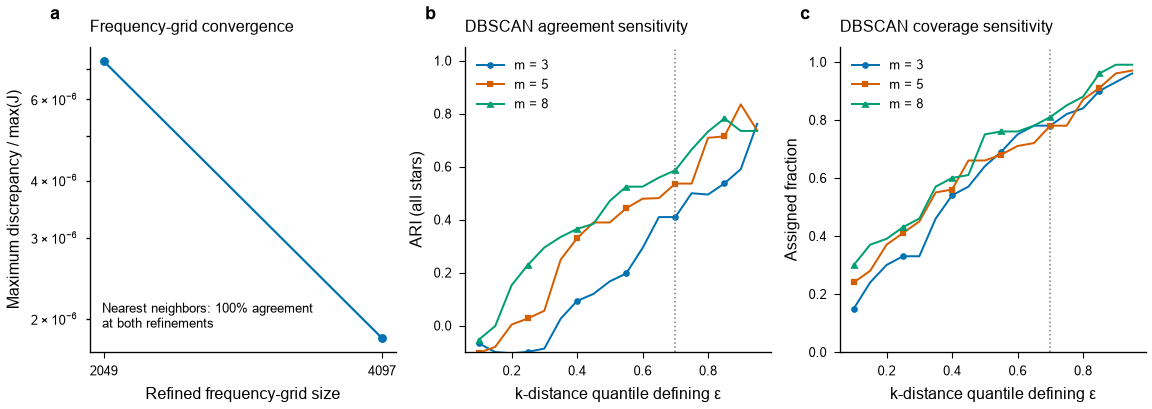

Figure 4 | Numerical and parameter checks. a, Successive refinements from 1025 to 2049 to 4097 frequencies compare squared-JDR matrices; every entry also satisfies rtol=10⁻³ and atol=10⁻⁸. Nearest-neighbor identities are unchanged. b,c, The full, predeclared DBSCAN sensitivity grid: neighborhood size m∈{3,5,8}, including the observation itself, and 18 k-distance quantiles from 0.10 to 0.95. The dotted line marks the primary quantile 0.70; the primary model has m=5. These external-score curves are post-fit diagnostics, not used to choose the reported model. The cohort is an exploratory local census, not held-out evaluation.

In [7]:
figure_directory = make_figures(OUTPUT)
captions = json.loads((figure_directory / 'captions.json').read_text())
for stem, caption in captions.items():
    display(Image(filename=str(figure_directory / f'{stem}_preview.png')))
    display(Markdown(caption))


## 7. Interpretation and reproducibility artifacts

These results describe the available local census. They do not establish a statistically significant winner, survey-independent generalization or reliable rare-subtype performance. They also do not constitute validation of fitted periods against independent catalog periods. A publishable astronomical conclusion needs those additional data checks; the notebook provides a transparent, reproducible experiment and journal-scale artwork.

A high assigned-only score from a density model must be read together with rejected-object counts and subtype retention. Stability quantiles address sensitivity to which objects were included, not all sources of scientific uncertainty.

In [8]:
display(Markdown(chr(10).join('- ' + item for item in summary['limitations'])))
provenance = json.loads((OUTPUT / 'provenance.json').read_text())
display(pd.Series(provenance['versions'], name='Recorded package version').to_frame())
display(pd.DataFrame({'artifact': ['cohort.csv', 'model_comparison.csv', 'cluster_labels.csv',
    'experiment.npz', 'subsampling_stability.csv', 'subsample_membership.json',
    'dbscan_sensitivity.csv', 'provenance.json', 'reproducibility.json', 'figures/CAPTIONS.md']}))
print('Experiment complete:', OUTPUT)


- Only one RRd; no reliable RRd class-level inference.
- Catalog subtype and sky region are imbalanced; region agreement is descriptive, not a causal confounding test.
- All-star ARI groups rejected points under the noise label; assigned-only metrics and coverage are also reported.
- Subsampling refits clustering on fixed fitted curves; period/photometry uncertainty is not propagated.
- No performance confidence intervals or best-model significance claims from this census.
- The standard spectral representation is version 2, not a verified reproduction of an unidentified JDR paper.

,Recorded package version
numpy,2.5.3
scipy,1.18.1
pandas,3.0.5
scikit-learn,1.9.1
astropy,8.0.1
matplotlib,3.11.2
threadpoolctl,3.6.0


,artifact
0,cohort.csv
1,model_comparison.csv
2,cluster_labels.csv
3,experiment.npz
4,subsampling_stability.csv
5,subsample_membership.json
6,dbscan_sensitivity.csv
7,provenance.json
8,reproducibility.json
9,figures/CAPTIONS.md


Experiment complete: /Users/francisco/code/JDR-Python/results/benchmark_100
